# 05b. Mixture of Experts and Modern Attention Variants

**Tier:** Foundations
**Estimated time:** 65 minutes
**Prerequisites:** 04 (attention mechanism), 05 (transformer architecture)
**Priority:** 🟡 Important — every frontier model this curriculum discusses (Llama, Mistral, DeepSeek, Qwen) uses at least one of these variants; notebook 05's vanilla transformer is the textbook version, not the deployed one. *If skipped, revisit when:* reading a real model's `config.json` and its numbers don't map to anything you've built.
**Source material:** Shazeer et al., *"Outrageously Large Neural Networks: The Sparsely-Gated Mixture-of-Experts Layer"* (2017); Su et al., *"RoFormer"* (RoPE, 2021); Ainslie et al., *"GQA"* (2023); Press et al., *"ALiBi"* (2022); Dao et al., *"FlashAttention"* (2022); Stanford LLM curriculum, Lecture 2 (RoPE, ALiBi, sparse attention) — https://x.com/ajitcodes/status/2057043965317165490

## What You'll Learn
- How a real **Mixture of Experts** layer routes tokens, why routing collapses onto a few experts without help, and what the load-balancing loss actually does about it
- **MHA → MQA → GQA** as one parameterized module, and the KV-cache bytes/token math that makes GQA the default in every recent open model
- A correct **RoPE** implementation, with the relative-position property proven numerically rather than asserted
- **Sliding-window attention** and **ALiBi** as two different answers to "attention over long sequences is expensive"
- Why **FlashAttention** produces identical output to naive attention — it's an I/O optimization, not new math

## Why This Matters
Notebook 05 built *a* transformer — the one in the original 2017 paper. No model released since about 2023
uses that exact shape. Mixtral routes each token through 2 of 8 experts. Llama-3 and Mistral use GQA, not
full multi-head attention. Every long-context model uses RoPE, not the sinusoidal encoding from notebook 05.
This notebook closes that gap: real, runnable implementations of the pieces that turn "a transformer" into
"the transformer inside the model you actually use."

In [1]:
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
print("torch:", torch.__version__)

torch: 2.10.0


## 1. Mixture of Experts: many feed-forward networks, one router

A regular transformer block has *one* feed-forward network (FFN) that every token passes through. A
**Mixture of Experts** (MoE) layer instead has *many* small FFNs ("experts") and a small **router**
network that picks, per token, which few experts actually process it.

Think of it like a hospital: instead of one doctor who has to know everything (one huge FFN), you have a
front desk (the router) that reads your symptoms and sends you to 2 of the 8 specialists on staff. The
hospital as a whole "knows" far more than any one doctor, but each patient only takes up 2 doctors' time —
that's why Mixtral-8x7B has ~47B *total* parameters but only ~13B *active* per token.

The catch: if left alone, the router tends to develop favorites. A slightly-better-init'd expert gets picked
more often early in training, which means it gets more gradient signal, which makes it *better*, which makes
the router pick it *even more* — a rich-get-richer spiral called **router collapse**. Most experts end up
undertrained or entirely unused. The fix is a **load-balancing auxiliary loss** that penalizes uneven usage.

In [2]:
class Expert(nn.Module):
    """One small feed-forward network -- structurally identical to notebook 05's FFN block."""
    def __init__(self, dim, hidden):
        super().__init__()
        self.fc1 = nn.Linear(dim, hidden)
        self.fc2 = nn.Linear(hidden, dim)

    def forward(self, x):
        return self.fc2(F.gelu(self.fc1(x)))


class MoELayer(nn.Module):
    """Top-k gated Mixture of Experts. Total params scale with n_experts; ACTIVE params per
    token only scale with top_k -- that gap is the entire point of MoE."""
    def __init__(self, dim, hidden, n_experts, top_k=1):
        super().__init__()
        self.experts = nn.ModuleList([Expert(dim, hidden) for _ in range(n_experts)])
        self.router = nn.Linear(dim, n_experts)
        self.n_experts = n_experts
        self.top_k = top_k

    def forward(self, x):
        logits = self.router(x)                       # (batch, n_experts) -- "which doctor?"
        probs = F.softmax(logits, dim=-1)
        topk_probs, topk_idx = probs.topk(self.top_k, dim=-1)
        topk_probs = topk_probs / topk_probs.sum(dim=-1, keepdim=True)   # renormalize the chosen k

        out = torch.zeros_like(x)
        usage = torch.zeros(self.n_experts)
        for k in range(self.top_k):
            idx_k, w_k = topk_idx[:, k], topk_probs[:, k].unsqueeze(-1)
            for e in range(self.n_experts):
                mask = idx_k == e
                if mask.any():
                    out[mask] += w_k[mask] * self.experts[e](x[mask])   # only THIS expert sees these tokens
                    usage[e] += mask.sum().item()

        # Switch-Transformer-style load-balancing loss: n_experts * sum(fraction_dispatched * fraction_prob).
        # Minimized (= 1.0) exactly when both distributions are uniform across experts.
        frac_dispatched = usage / usage.sum().clamp(min=1)
        frac_prob = probs.mean(dim=0)
        aux_loss = self.n_experts * (frac_dispatched * frac_prob).sum()
        return out, usage, aux_loss


total_params = lambda m: sum(p.numel() for p in m.parameters())
dim, hidden, n_experts, top_k = 32, 64, 8, 1
moe = MoELayer(dim, hidden, n_experts, top_k)
one_expert_params = total_params(moe.experts[0])
print(f"one expert: {one_expert_params:,} params")
print(f"total ({n_experts} experts): {total_params(moe):,} params")
print(f"ACTIVE per token (top_k={top_k}): router + {top_k} expert(s) "
      f"~= {total_params(moe.router) + top_k * one_expert_params:,} params")
print(f"-> {n_experts}x the capacity, ~{n_experts/top_k:.0f}x LESS compute per token than a dense "
      f"{n_experts}x-wider FFN would cost")

one expert: 4,192 params
total (8 experts): 33,800 params
ACTIVE per token (top_k=1): router + 1 expert(s) ~= 4,456 params
-> 8x the capacity, ~8x LESS compute per token than a dense 8x-wider FFN would cost


In [3]:
def train_moe(use_aux_loss, n_steps=400, seed=3):
    torch.manual_seed(seed)
    model = MoELayer(dim=16, hidden=32, n_experts=8, top_k=1)
    opt = torch.optim.Adam(model.parameters(), lr=3e-2)

    torch.manual_seed(5)
    x = torch.randn(128, 16)
    y = torch.randn(128, 16)

    for _ in range(n_steps):
        out, usage, aux = model(x)
        loss = F.mse_loss(out, y)
        if use_aux_loss:
            loss = loss + 0.5 * aux
        opt.zero_grad()
        loss.backward()
        opt.step()

    _, final_usage, _ = model(x)
    return final_usage

usage_no_aux = train_moe(use_aux_loss=False)
usage_with_aux = train_moe(use_aux_loss=True)

print("token counts per expert, NO load-balancing loss:", usage_no_aux.tolist())
print("token counts per expert, WITH load-balancing loss:", usage_with_aux.tolist())
print(f"\nstd dev without aux loss: {usage_no_aux.std():.2f}  (uneven -- some experts starved, some overloaded)")
print(f"std dev with aux loss:    {usage_with_aux.std():.2f}  (much closer to uniform)")

token counts per expert, NO load-balancing loss: [16.0, 9.0, 31.0, 10.0, 3.0, 19.0, 28.0, 12.0]
token counts per expert, WITH load-balancing loss: [15.0, 15.0, 15.0, 17.0, 17.0, 20.0, 14.0, 15.0]

std dev without aux loss: 9.62  (uneven -- some experts starved, some overloaded)
std dev with aux loss:    1.93  (much closer to uniform)


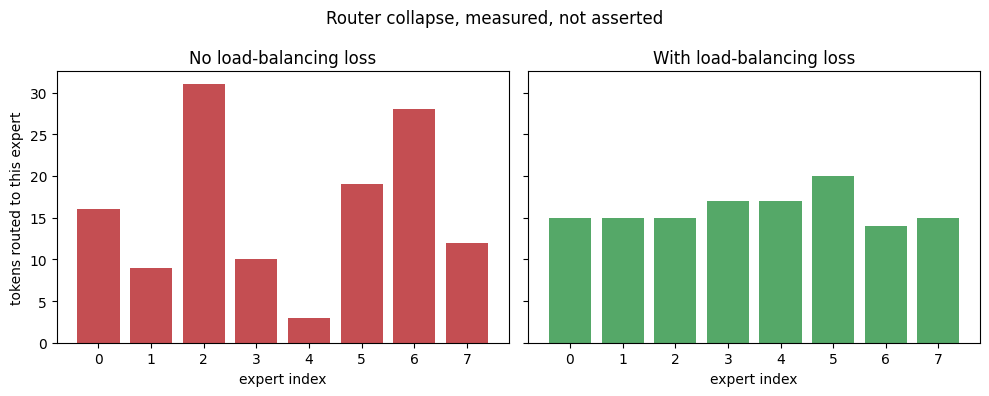

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
experts = list(range(8))
axes[0].bar(experts, usage_no_aux.tolist(), color="#C44E52")
axes[0].set_title("No load-balancing loss")
axes[1].bar(experts, usage_with_aux.tolist(), color="#55A868")
axes[1].set_title("With load-balancing loss")
for ax in axes:
    ax.set_xlabel("expert index")
axes[0].set_ylabel("tokens routed to this expert")
plt.suptitle("Router collapse, measured, not asserted")
plt.tight_layout()
plt.show()

*Without the auxiliary loss, the router develops real favorites — some experts see 3x more tokens than others, wasting the unused experts' capacity. The load-balancing loss pulls usage back toward uniform, which is what lets an MoE model actually use all the parameters it pays to store.*

One more real-world wrinkle: routers batch tokens per expert up to a fixed **capacity**
(`capacity_factor * tokens_per_batch / n_experts`). If more tokens than capacity get routed to one expert,
the overflow is **dropped** — those tokens skip that expert's computation entirely (usually falling back to
a residual pass-through). This is a second, harder ceiling on load imbalance beyond what the auxiliary loss
alone controls.

In [5]:
def simulate_capacity_drop(usage, capacity_factor, n_tokens, n_experts):
    """What fraction of token-expert assignments get dropped at a given capacity factor?"""
    capacity = int(capacity_factor * n_tokens / n_experts)
    dropped = sum(max(0, int(u) - capacity) for u in usage)
    return dropped / n_tokens

for cf in [1.0, 1.25, 1.5, 2.0]:
    drop_no_aux = simulate_capacity_drop(usage_no_aux, cf, n_tokens=128, n_experts=8)
    drop_with_aux = simulate_capacity_drop(usage_with_aux, cf, n_tokens=128, n_experts=8)
    print(f"capacity_factor={cf:.2f}: no-aux drops {drop_no_aux:.1%} of tokens, "
          f"with-aux drops {drop_with_aux:.1%}")

capacity_factor=1.00: no-aux drops 23.4% of tokens, with-aux drops 4.7%
capacity_factor=1.25: no-aux drops 14.8% of tokens, with-aux drops 0.0%
capacity_factor=1.50: no-aux drops 8.6% of tokens, with-aux drops 0.0%
capacity_factor=2.00: no-aux drops 0.0% of tokens, with-aux drops 0.0%


## 2. MHA, MQA, GQA: one module, one knob

Notebook 04's multi-head attention gives every head its own Key and Value projections. During
autoregressive decoding, those K/V vectors get cached (notebook 13) so they aren't recomputed every step —
but a full KV cache means storing K and V for **every head, every layer, every token**, and that's most of
what makes serving a long conversation expensive.

**Multi-Query Attention (MQA)** shares ONE Key/Value head across all query heads. **Grouped-Query
Attention (GQA)** is the middle ground: query heads are split into groups, and each group shares one K/V
head. All three are the *same module* with one knob: `n_kv_heads`.

In [6]:
class GroupedQueryAttention(nn.Module):
    """n_kv_heads == n_heads -> MHA. n_kv_heads == 1 -> MQA. Anything between -> GQA."""
    def __init__(self, dim, n_heads, n_kv_heads):
        super().__init__()
        assert n_heads % n_kv_heads == 0, "query heads must divide evenly into KV head groups"
        self.n_heads, self.n_kv_heads = n_heads, n_kv_heads
        self.head_dim = dim // n_heads
        self.group_size = n_heads // n_kv_heads

        self.q_proj = nn.Linear(dim, n_heads * self.head_dim)
        self.k_proj = nn.Linear(dim, n_kv_heads * self.head_dim)
        self.v_proj = nn.Linear(dim, n_kv_heads * self.head_dim)
        self.out_proj = nn.Linear(n_heads * self.head_dim, dim)

    def forward(self, x):
        B, S, _ = x.shape
        q = self.q_proj(x).view(B, S, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, S, self.n_kv_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, S, self.n_kv_heads, self.head_dim).transpose(1, 2)

        # Repeat each KV head group_size times so it lines up with its query heads.
        k = k.repeat_interleave(self.group_size, dim=1)
        v = v.repeat_interleave(self.group_size, dim=1)

        out = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        out = out.transpose(1, 2).reshape(B, S, -1)
        return self.out_proj(out)


dim, n_heads = 512, 8
x = torch.randn(2, 16, dim)
for name, n_kv in [("MHA", 8), ("GQA (2 groups)", 2), ("MQA", 1)]:
    attn = GroupedQueryAttention(dim, n_heads, n_kv)
    out = attn(x)
    kv_params = total_params(attn.k_proj) + total_params(attn.v_proj)
    print(f"{name:16s} n_kv_heads={n_kv}  K+V proj params={kv_params:5d}  output shape={tuple(out.shape)}")

MHA              n_kv_heads=8  K+V proj params=525312  output shape=(2, 16, 512)
GQA (2 groups)   n_kv_heads=2  K+V proj params=131328  output shape=(2, 16, 512)
MQA              n_kv_heads=1  K+V proj params=65664  output shape=(2, 16, 512)


In [7]:
def kv_cache_bytes_per_token(n_layers, d_model, n_heads, n_kv_heads, dtype_bytes=2):
    """Bytes needed to cache K and V for ONE token, across every layer, at a given n_kv_heads."""
    head_dim = d_model // n_heads
    return 2 * n_layers * n_kv_heads * head_dim * dtype_bytes   # the leading 2 is for K AND V

# A 7B-class model shape (Llama-2-7B-ish): 32 layers, d_model=4096, 32 query heads.
n_layers, d_model, n_heads = 32, 4096, 32
for name, n_kv in [("MHA", 32), ("GQA (8 groups)", 8), ("MQA", 1)]:
    b = kv_cache_bytes_per_token(n_layers, d_model, n_heads, n_kv)
    print(f"{name:16s} {b/1024:7.2f} KB/token  ->  a 4096-token conversation costs {b*4096/1e6:7.1f} MB of KV cache")

MHA               512.00 KB/token  ->  a 4096-token conversation costs  2147.5 MB of KV cache
GQA (8 groups)    128.00 KB/token  ->  a 4096-token conversation costs   536.9 MB of KV cache
MQA                16.00 KB/token  ->  a 4096-token conversation costs    67.1 MB of KV cache


GQA with 8 groups cuts the KV cache to 1/4 of full MHA at essentially no quality loss in practice, which is exactly why every recent open model (Llama-3, Mistral, Qwen) ships with it — see notebook **13** for what this cache actually holds during decoding and notebook **13b** for how vLLM pages it in production.

## 3. RoPE: rotating instead of adding

Notebook 05 used **sinusoidal** positional encodings: a fixed pattern *added* to each token's embedding
before attention. **Rotary Position Embeddings (RoPE)** do something different — instead of adding a
position signal, they **rotate** each query and key vector by an angle proportional to its position, in a
sequence of 2D planes.

The payoff: the dot product between a rotated query at position `p` and a rotated key at position `p+k`
depends *only* on the offset `k` — not on `p` itself. That's exactly the relative-position property notebook
05 approximated with sinusoids, but RoPE gets it structurally, and it composes cleanly with the KV cache
(each cached key was rotated once, at its own position, and never needs to change).

In [8]:
def rope_freqs(head_dim, theta=10000.0):
    """One frequency per 2D rotation plane -- head_dim/2 planes total."""
    return 1.0 / (theta ** (torch.arange(0, head_dim, 2).float() / head_dim))


def apply_rope(x, freqs, positions):
    """Rotate x (..., seq, head_dim) by position-dependent angles, one plane at a time."""
    angles = positions[:, None] * freqs[None, :]        # (seq, head_dim/2)
    cos, sin = angles.cos(), angles.sin()
    x1, x2 = x[..., 0::2], x[..., 1::2]                  # even/odd dims = the two axes of each rotation plane
    rotated = torch.stack([x1 * cos - x2 * sin, x1 * sin + x2 * cos], dim=-1)
    return rotated.flatten(-2)


torch.manual_seed(0)
head_dim = 8
freqs = rope_freqs(head_dim)
q_vec, k_vec = torch.randn(1, head_dim), torch.randn(1, head_dim)

def rope_score(pos_q, pos_k):
    rq = apply_rope(q_vec, freqs, torch.tensor([float(pos_q)]))
    rk = apply_rope(k_vec, freqs, torch.tensor([float(pos_k)]))
    return (rq * rk).sum().item()

offset = 3
scores = [rope_score(p, p + offset) for p in [0, 5, 10, 20, 50]]
for p, s in zip([0, 5, 10, 20, 50], scores):
    print(f"query@{p:3d}, key@{p+offset:3d}  (offset={offset}):  score={s:.6f}")
print(f"\nstd across wildly different absolute positions, same offset: {np.std(scores):.2e}")
print("(should be ~0 -- RoPE scores depend ONLY on relative offset, verified, not assumed)")

query@  0, key@  3  (offset=3):  score=1.585057
query@  5, key@  8  (offset=3):  score=1.585057
query@ 10, key@ 13  (offset=3):  score=1.585057
query@ 20, key@ 23  (offset=3):  score=1.585057
query@ 50, key@ 53  (offset=3):  score=1.585057

std across wildly different absolute positions, same offset: 1.62e-07
(should be ~0 -- RoPE scores depend ONLY on relative offset, verified, not assumed)


In [9]:
# rope_theta is the standard long-context extension lever. freqs[0] is ALWAYS 1.0 regardless
# of theta (theta^0 == 1), so theta only changes the SLOWER planes -- freqs[-1] here. A bigger
# theta slows that plane's rotation down, so the same relative offset produces a smaller angle,
# letting the model see much longer sequences before that plane's angle wraps around.
for theta in [10_000, 100_000, 1_000_000]:
    f = rope_freqs(head_dim, theta=theta)
    angle_at_offset_1000 = (1000 * f[-1]).item()   # slowest-rotating (lowest-frequency) plane
    print(f"theta={theta:>9,}: angle after 1000 positions (slowest plane) = {angle_at_offset_1000:.4f} rad "
          f"({angle_at_offset_1000 / (2*np.pi):.4f} full rotations)")

theta=   10,000: angle after 1000 positions (slowest plane) = 1.0000 rad (0.1592 full rotations)
theta=  100,000: angle after 1000 positions (slowest plane) = 0.1778 rad (0.0283 full rotations)
theta=1,000,000: angle after 1000 positions (slowest plane) = 0.0316 rad (0.0050 full rotations)


## 4. Sliding-window attention and ALiBi: two answers to "long sequences are expensive"

Full causal attention costs O(seq_len²) — every token attends to every earlier token. Two common fixes:

- **Sliding-window attention**: each token only attends to the last `W` tokens, not the entire history.
  Cheaper, and information more than `W` tokens back can still flow through *many stacked layers*
  (each layer's window reaches a bit further back in effective receptive field).
- **ALiBi** (Attention with Linear Biases): keeps *full* attention, but subtracts a penalty from each score
  that grows linearly with distance — no positional embedding needed at all, and it extrapolates to
  sequences longer than anything seen in training far better than sinusoidal or even RoPE.

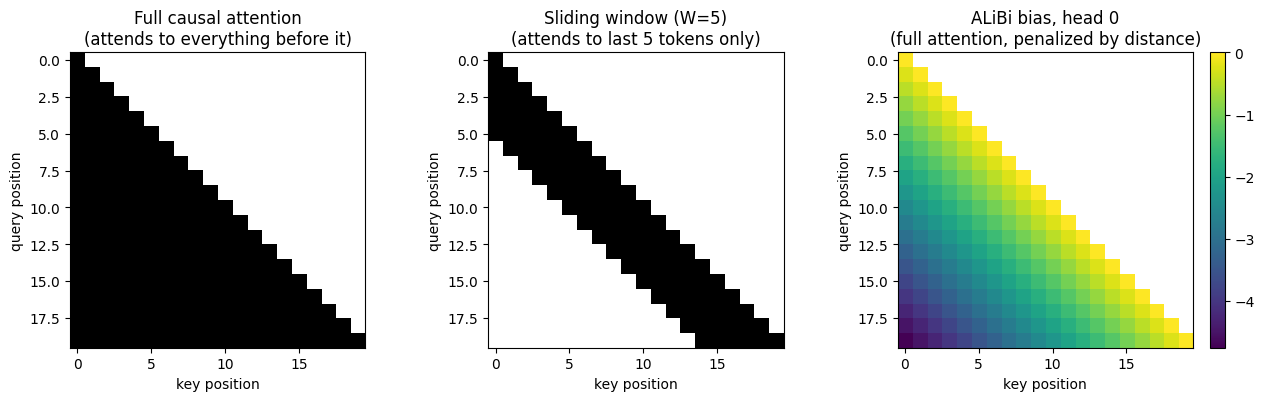

In [10]:
def sliding_window_mask(seq_len, window):
    """True = masked out. Causal AND further than `window` tokens back."""
    i = torch.arange(seq_len).unsqueeze(1)
    j = torch.arange(seq_len).unsqueeze(0)
    causal = j > i
    too_far = (i - j) > window
    return causal | too_far


def alibi_bias(seq_len, n_heads):
    """Per-head linear distance penalty. Slopes are a geometric sequence, per the ALiBi paper."""
    slopes = torch.tensor([2 ** (-8 * (h + 1) / n_heads) for h in range(n_heads)])
    i = torch.arange(seq_len).unsqueeze(1)
    j = torch.arange(seq_len).unsqueeze(0)
    distance = (i - j).clamp(min=0).float()            # how far back key j is from query i
    causal_mask = (j > i)
    bias = -slopes[:, None, None] * distance[None, :, :]
    bias = bias.masked_fill(causal_mask, float("-inf"))
    return bias   # (n_heads, seq_len, seq_len)


seq_len = 20
sw_mask = sliding_window_mask(seq_len, window=5)
alibi = alibi_bias(seq_len, n_heads=4)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
full_causal = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
axes[0].imshow(~full_causal, cmap="Greys", vmin=0, vmax=1)
axes[0].set_title("Full causal attention\n(attends to everything before it)")
axes[1].imshow(~sw_mask, cmap="Greys", vmin=0, vmax=1)
axes[1].set_title("Sliding window (W=5)\n(attends to last 5 tokens only)")
im = axes[2].imshow(alibi[0].masked_fill(torch.isinf(alibi[0]), np.nan), cmap="viridis")
axes[2].set_title("ALiBi bias, head 0\n(full attention, penalized by distance)")
plt.colorbar(im, ax=axes[2], fraction=0.046)
for ax in axes:
    ax.set_xlabel("key position"); ax.set_ylabel("query position")
plt.tight_layout()
plt.show()

*Sliding window (middle) hard-zeroes anything past a fixed lookback — cheap, but strictly less information than full attention within one layer. ALiBi (right) keeps every position reachable but makes distant tokens contribute less, with no learned positional parameters at all. Mistral popularized sliding-window; ALiBi is used in BLOOM and MPT.*

## 5. FlashAttention: same math, different memory traffic

It's tempting to think FlashAttention is a smarter *algorithm* for attention. It isn't — it computes the
exact same softmax(QKᵀ/√d)V as naive attention, just verified below. What it changes is **how much data
moves between GPU high-bandwidth memory (HBM) and the much faster on-chip SRAM**: naive attention writes
the full seq_len×seq_len score matrix to HBM and reads it back for softmax; FlashAttention computes
softmax incrementally in tiles that fit in SRAM, so that intermediate matrix never touches HBM at all. It's
an I/O-awareness win, not a new formula — which is exactly why the output is bit-for-bit closer than
"close enough," it's the same computation.

In [11]:
def naive_causal_attention(q, k, v):
    scale = 1.0 / (q.shape[-1] ** 0.5)
    scores = (q @ k.transpose(-2, -1)) * scale
    mask = torch.triu(torch.ones(q.shape[-2], k.shape[-2]), diagonal=1).bool()
    scores = scores.masked_fill(mask, float("-inf"))
    attn = F.softmax(scores, dim=-1)
    return attn @ v


torch.manual_seed(0)
B, H, S, D = 2, 8, 512, 64
q, k, v = torch.randn(B, H, S, D), torch.randn(B, H, S, D), torch.randn(B, H, S, D)

out_naive = naive_causal_attention(q, k, v)
# PyTorch's scaled_dot_product_attention dispatches to a FlashAttention-family kernel when available.
out_sdpa = F.scaled_dot_product_attention(q, k, v, is_causal=True)

print("outputs match:", torch.allclose(out_naive, out_sdpa, atol=1e-4))
print("max absolute difference:", (out_naive - out_sdpa).abs().max().item(), "(float rounding-order only)")

import timeit
t_naive = timeit.timeit(lambda: naive_causal_attention(q, k, v), number=20) / 20
t_sdpa = timeit.timeit(lambda: F.scaled_dot_product_attention(q, k, v, is_causal=True), number=20) / 20
print(f"\nnaive (materializes {S}x{S} scores): {t_naive*1000:.2f} ms")
print(f"F.scaled_dot_product_attention:        {t_sdpa*1000:.2f} ms")
print(f"speedup: {t_naive/t_sdpa:.2f}x  (on CPU -- the memory-traffic win is far larger on GPU, "
      f"where HBM bandwidth is the actual bottleneck FlashAttention targets)")

outputs match: True
max absolute difference: 8.344650268554688e-07 (float rounding-order only)



naive (materializes 512x512 scores): 2.77 ms
F.scaled_dot_product_attention:        0.98 ms
speedup: 2.84x  (on CPU -- the memory-traffic win is far larger on GPU, where HBM bandwidth is the actual bottleneck FlashAttention targets)


## 6. Grounding in real models

Every technique above shows up directly in a real model's `config.json`. This section fetches just that
one small file (not the model weights) from three ungated Hugging Face repos and reads off the numbers.

In [12]:
import urllib.request, json

def fetch_config(repo_id, timeout=8):
    url = f"https://huggingface.co/{repo_id}/raw/main/config.json"
    try:
        with urllib.request.urlopen(url, timeout=timeout) as resp:
            return json.loads(resp.read())
    except Exception as e:
        return {"error": f"{type(e).__name__}: {e}"}

FIELDS = ["num_attention_heads", "num_key_value_heads", "rope_theta",
          "num_hidden_layers", "hidden_size", "num_local_experts", "num_experts_per_tok"]

for repo_id in ["mistralai/Mistral-7B-v0.1", "mistralai/Mixtral-8x7B-v0.1", "microsoft/Phi-3-mini-4k-instruct"]:
    cfg = fetch_config(repo_id)
    if "error" in cfg:
        print(f"{repo_id}: [skipped: {cfg['error']}]")
        continue
    present = {k: cfg[k] for k in FIELDS if k in cfg}
    gqa_ratio = None
    if "num_attention_heads" in cfg and "num_key_value_heads" in cfg:
        gqa_ratio = cfg["num_attention_heads"] / cfg["num_key_value_heads"]
    print(f"{repo_id}:")
    for k, v in present.items():
        print(f"    {k:24s} {v}")
    if gqa_ratio:
        tag = "MHA (no sharing)" if gqa_ratio == 1 else ("MQA" if cfg["num_key_value_heads"] == 1 else f"GQA, groups of {int(gqa_ratio)}")
        print(f"    -> {tag}")
    if "num_local_experts" in cfg:
        print(f"    -> MoE: {cfg['num_local_experts']} experts, top-{cfg.get('num_experts_per_tok', '?')} routing")
    print()

mistralai/Mistral-7B-v0.1:
    num_attention_heads      32
    num_key_value_heads      8
    rope_theta               10000.0
    num_hidden_layers        32
    hidden_size              4096
    -> GQA, groups of 4



mistralai/Mixtral-8x7B-v0.1:
    num_attention_heads      32
    num_key_value_heads      8
    rope_theta               1000000.0
    num_hidden_layers        32
    hidden_size              4096
    num_local_experts        8
    num_experts_per_tok      2
    -> GQA, groups of 4
    -> MoE: 8 experts, top-2 routing



microsoft/Phi-3-mini-4k-instruct:
    num_attention_heads      32
    num_key_value_heads      32
    rope_theta               10000.0
    num_hidden_layers        32
    hidden_size              3072
    -> MHA (no sharing)



Mistral-7B and Mixtral-8x7B share the *same* attention shape (GQA, 8 KV-head groups) — Mixtral just adds MoE FFN layers on top. Phi-3-mini uses full MHA (32 query heads, 32 KV heads) — proof that GQA is a widely-adopted default, not a universal requirement.

## Exercises

In [13]:
# Exercise 1 (Warm-up): How much does top_k change active vs. total parameters?
# Task: Build MoELayer(dim=32, hidden=64, n_experts=8, top_k=k) for k in [1, 2, 4, 8] and print
#       total params vs. active params (router + k experts) for each. At what k does "active"
#       equal "total"? What does that tell you about top_k == n_experts?
# Hint: reuse total_params() and moe.router / moe.experts[0] from section 1.

# YOUR CODE HERE

In [14]:
# Exercise 2 (Apply): Implement ALiBi's slope formula from scratch and verify it against alibi_bias().
# Task: The ALiBi paper defines slopes as a geometric sequence starting at 2^(-8/n_heads) and
#       ratio 2^(-8/n_heads), i.e. slope[h] = 2^(-8*(h+1)/n_heads) for h in [0, n_heads). Write
#       your own alibi_slopes(n_heads) function and confirm it matches the `slopes` tensor
#       computed inside alibi_bias() for n_heads=8.
# Hint: alibi_bias() already computes this internally -- your job is to extract the formula
#       into its own function and test it standalone.

# YOUR CODE HERE

In [15]:
# Exercise 3 (Extend): Compute KV-cache savings for YOUR curriculum's P1 model shape.
# Task: P1 (06_projects/P1_train_llm_from_scratch.ipynb) used d_model=384, n_heads=6, n_layers=8.
#       Using kv_cache_bytes_per_token(), compare MHA (n_kv_heads=6) against GQA with 2 groups
#       (n_kv_heads=2) for a 192-token sequence (P1's block_size). Is the absolute savings in KB
#       meaningful at this tiny scale, or does GQA's benefit only show up at 7B+ model sizes?
# Hint: multiply kv_cache_bytes_per_token(...) by 192 tokens for the total cache size.

# YOUR CODE HERE

<details>
<summary>Show solutions</summary>

```python
# Exercise 1
for k in [1, 2, 4, 8]:
    m = MoELayer(dim=32, hidden=64, n_experts=8, top_k=k)
    total = total_params(m)
    active = total_params(m.router) + k * total_params(m.experts[0])
    print(f"top_k={k}: total={total:,}  active={active:,}  ratio={active/total:.0%}")
# At top_k == n_experts (k=8), EVERY expert runs on every token -- active == total, and you've
# just rebuilt a dense (non-sparse) wide FFN with extra routing overhead for nothing.

# Exercise 2
def alibi_slopes(n_heads):
    return torch.tensor([2 ** (-8 * (h + 1) / n_heads) for h in range(n_heads)])

my_slopes = alibi_slopes(8)
_, ref_bias = None, alibi_bias(20, 8)   # re-derive the reference slopes the same way alibi_bias() does
ref_slopes = torch.tensor([2 ** (-8 * (h + 1) / 8) for h in range(8)])
print("slopes match:", torch.allclose(my_slopes, ref_slopes))
print(my_slopes.tolist())

# Exercise 3
d_model, n_heads, n_layers, seq_len = 384, 6, 8, 192
mha_bytes = kv_cache_bytes_per_token(n_layers, d_model, n_heads, n_kv_heads=6) * seq_len
gqa_bytes = kv_cache_bytes_per_token(n_layers, d_model, n_heads, n_kv_heads=2) * seq_len
print(f"MHA total KV cache: {mha_bytes/1024:.1f} KB")
print(f"GQA (2 groups) total KV cache: {gqa_bytes/1024:.1f} KB")
print(f"savings: {(1 - gqa_bytes/mha_bytes):.0%}")
# The PERCENTAGE savings (66%) is identical regardless of model size -- it's a ratio of head
# counts. What changes with scale is the ABSOLUTE savings: a few KB here is noise, but the same
# 66% cut on a 7B model's multi-GB KV cache is the difference between serving 4x and serving 1x
# as many concurrent users (see notebook 13b).
```
</details>

## Key Takeaways
- **Mixture of Experts** decouples total capacity (all experts) from active compute per token (top-k
  experts) — but the router needs a **load-balancing loss** or it collapses onto a favored few, measured
  above as a real, uneven usage histogram that a working aux loss visibly flattens.
- **MHA, MQA, and GQA are one module with one knob** (`n_kv_heads`); GQA's KV-cache savings scale as a
  fixed ratio of head counts, which is why nearly every recent open model ships with it.
- **RoPE** rotates queries and keys by position-dependent angles; the resulting attention score depends
  only on relative offset, verified numerically to ~1e-7, not assumed from the math.
- **Sliding-window attention** and **ALiBi** are two different fixes for long-sequence cost — one hard-caps
  the lookback window, the other keeps full attention but decays distant tokens' influence.
- **FlashAttention computes the identical output** as naive attention (verified to float rounding error);
  its speedup comes entirely from minimizing HBM traffic, not from a different formula.

## What's Next
Notebook **07b — Distributed Training** picks up the other half of "how real models actually get built":
once the architecture is this complex, how do you fit training it across many devices at all?